**Dwonloading the Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

**Loading the Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Housing.csv to Housing.csv


In [ ]:
df = pd.read_csv('Housing.csv')

**Variable List**

In [ ]:
varlist = ['mainroad', 'guestroom', 'basement','hotwaterheating', 'aircondition', 'prefarea']

def binary_map(x):
  return x.map({'yes': 1, "no": 0})

  df[varlist] = df[varlist].apply(binary_map)

  status = pd.get_dummies(df['furnishingstatus'], drop_first =True)
  df = pd.concat([df, status], axis = 1)
  df.drop(['furnishingstatus'],axis = 1, inplace = True)


In [ ]:
print(df.columns)


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
# First, ensuring that all categorical columns are numerical.
# Applied them here to ensure X contains only numerical values before model training.

# Columns with 'yes'/'no' values to be converted to 1/0
# :> 'aircondition' from the original varlist in mHFu8cic5G94 is corrected to 'airconditioning'
# to match the actual column name in the DataFrame (as seen in df.columns output).
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'yes': 1, 'no': 0})

# Handled 'furnishingstatus' column using one-hot encoding.
if 'furnishingstatus' in df.columns:
    status = pd.get_dummies(df['furnishingstatus'], drop_first=True, dtype=int)
    df = pd.concat([df, status], axis=1)
    df.drop(['furnishingstatus'], axis=1, inplace=True)

# Now, defined X and y from the preprocessed DataFrame.
# The df at this point has all relevant categorical columns converted to numeric.
X = df.drop('price', axis = 1)
y = df['price']

# Splited the data into training and testing sets.
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state = 100)

# Initialized and train the Linear Regression model.
model = LinearRegression()
model.fit(X_train, y_train)

# Made predictions on the test set.
y_pred = model.predict(X_test)

Mean Absolute Error : 785292.30
Root Mean Squared Error : 1061661.81


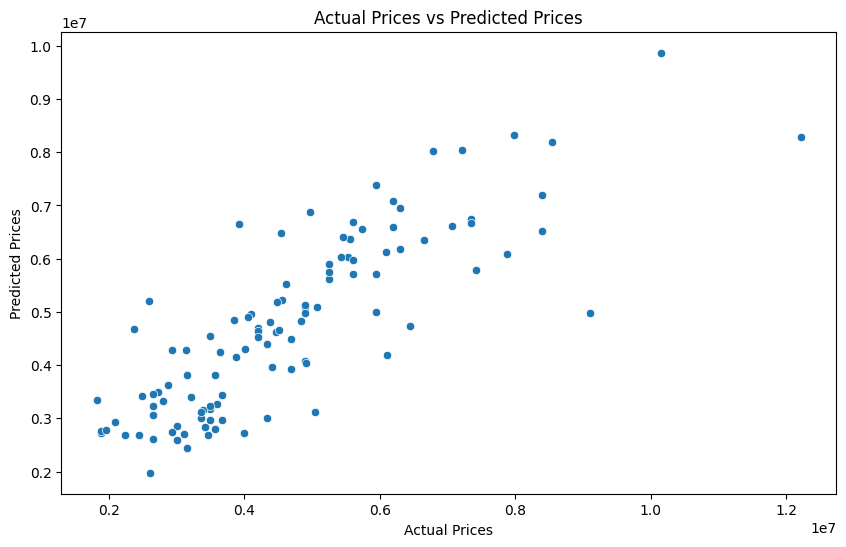

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs Predicted Prices')
plt.show()





In [ ]:
from google.colab import files
import pandas as pd

df.to_csv('Task6.csv', index=False)

files.download('Task6.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>